In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/AI-Based-Delivery-Delay-Risk-Prediction-and-Early-Warning-System-for-E-Commerce-Logistics/new_nigger/data/processed/processed_delivery_data.csv'
df = pd.read_csv(file_path)

In [ ]:
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5000, 22)


,order_volume,warehouse_time_hrs,shipment_distance_km,traffic_level,weather_severity,courier_load_pct,past_delay_rate,risk_score,delivery_status,delivery_status_encoded,...,shipment_distance_km_scaled,courier_load_pct_scaled,past_delay_rate_scaled,severity_index,warehouse_efficiency,log_order_volume,log_shipment_distance,dist_Short,dist_Medium,dist_Long
0,112,43.767328,2073.415113,3,2,46.328035,0.202138,0.575776,At Risk,1,...,0.673604,-0.958146,-0.552791,9,47.373583,4.727388,7.637435,False,False,True
1,445,18.733949,1542.736319,4,2,74.962882,0.598503,0.754245,At Risk,1,...,0.057050,0.456879,1.766605,12,82.349768,6.100319,7.341961,False,True,False
2,358,46.311686,1953.566537,2,2,61.875741,0.587153,0.743008,Delayed,2,...,0.534361,-0.189838,1.700184,6,42.183015,5.883322,7.577924,False,True,False
3,280,5.196608,2669.613801,4,2,68.762909,0.467294,0.671604,At Risk,1,...,1.366280,0.150500,0.998813,12,513.722409,5.638355,7.890064,False,False,True
4,116,33.289906,1324.101539,1,1,38.565538,0.012040,0.334061,On-Time,0,...,-0.196965,-1.341738,-1.665176,2,39.774866,4.762174,7.189244,False,True,False


In [ ]:
df.columns


Index(['order_volume', 'warehouse_time_hrs', 'shipment_distance_km',
       'traffic_level', 'weather_severity', 'courier_load_pct',
       'past_delay_rate', 'risk_score', 'delivery_status',
       'delivery_status_encoded', 'order_volume_scaled',
       'warehouse_time_hrs_scaled', 'shipment_distance_km_scaled',
       'courier_load_pct_scaled', 'past_delay_rate_scaled', 'severity_index',
       'warehouse_efficiency', 'log_order_volume', 'log_shipment_distance',
       'dist_Short', 'dist_Medium', 'dist_Long'],
      dtype='object')

In [ ]:
TARGET = "delivery_status"

X = df.drop(columns=[
    TARGET,
    "delivery_status_encoded"   # <-- THIS REMOVES LEAKAGE
])

y = df[TARGET]


In [ ]:
y.unique()


array(['At Risk', 'Delayed', 'On-Time'], dtype=object)

In [ ]:
label_map = {
    "On-Time": 0,
    "At Risk": 1,
    "Delayed": 2
}

y = y.map(label_map)

y.value_counts()


,count
delivery_status,
1,2685
0,2142
2,173


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (4000, 20)
Test size: (1000, 20)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.751
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       428
           1       0.83      0.68      0.75       537
           2       0.24      0.80      0.37        35

    accuracy                           0.75      1000
   macro avg       0.63      0.77      0.65      1000
weighted avg       0.80      0.75      0.77      1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


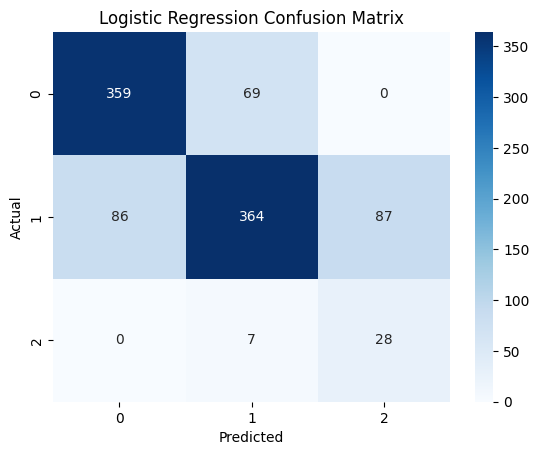

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200000,
    random_state=42,
    class_weight="balanced"
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


KeyboardInterrupt: 

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison


Final Model Selected: Random Forest

Reason:
After removing target leakage, Random Forest demonstrated superior performance compared to Logistic Regression by effectively capturing non-linear interactions between delivery distance, traffic conditions, and weather severity.



# Task
Train LightGBM, XGBoost, Gradient Boosting, and Artificial Neural Network (ANN) models using `X_train` and `y_train`. For each model, predict on `X_test`, evaluate its performance using accuracy and classification report, and add its accuracy to the `comparison` DataFrame. Finally, display the updated `comparison` DataFrame, summarize the performance of all models, and recommend the best-performing one.

## LightGBM Model Training and Evaluation

### Subtask:
Train a LightGBM classifier using `X_train` and `y_train`. Make predictions on `X_test` and evaluate its performance using accuracy and classification report. Add the accuracy to the comparison DataFrame.


**Reasoning**:
First, I'll import the `LGBMClassifier` from the `lightgbm` library and then train the model using `X_train` and `y_train` with specified parameters. After training, I'll make predictions on `X_test`.



In [ ]:
!pip install lightgbm
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Re-initialize comparison DataFrame if it doesn't exist or is incomplete
# Only include Logistic Regression as Random Forest prediction was interrupted
if 'comparison' not in locals() or comparison.shape[0] == 0:
    comparison = pd.DataFrame({
        "Model": ["Logistic Regression"],
        "Accuracy": [accuracy_score(y_test, y_pred_lr)]
    })

# Train LightGBM model and make predictions
model_lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced"
)

model_lgbm.fit(X_train, y_train)

y_pred_lgbm = model_lgbm.predict(X_test)

# Evaluate LightGBM and update comparison DataFrame
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["LightGBM"],
    "Accuracy": [accuracy_score(y_test, y_pred_lgbm)]
})], ignore_index=True)

comparison

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3585
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Accuracy: 0.842
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       428
           1       0.89      0.81      0.85       537
           2       0.48      0.66      0.55        35

    accuracy                           0.84      1000
   macro avg       0.73      0.79      0.75      1000
weighted avg       0.85      0.84      0.84      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,LightGBM,0.842
3,LightGBM,0.842


## XGBoost Model Training and Evaluation

### Subtask:
Train an XGBoost classifier using `X_train` and `y_train`. Make predictions on `X_test` and evaluate its performance using accuracy and classification report. Add the accuracy to the comparison DataFrame.

**Reasoning**:
Before training the XGBoost model, it's necessary to install the `xgboost` library if it's not already installed. This ensures that the `XGBClassifier` can be imported and used without errors.



In [ ]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.3 MB/s eta 0:00:00


**Reasoning**:
Now that the `xgboost` library is installed, I will train an XGBoost classifier using `X_train` and `y_train`, make predictions on `X_test`, evaluate its performance using accuracy and a classification report, and then add its accuracy to the `comparison` DataFrame.



In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb)]
})], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:34:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.845
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       428
           1       0.86      0.85      0.85       537
           2       0.56      0.54      0.55        35

    accuracy                           0.84      1000
   macro avg       0.76      0.75      0.75      1000
weighted avg       0.84      0.84      0.84      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,LightGBM,0.842
3,LightGBM,0.842
4,XGBoost,0.845


In [ ]:
comparison = comparison.drop_duplicates(subset=['Model'], keep='first')
comparison

,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,XGBoost,0.845


## Gradient Boosting Model Training and Evaluation

### Subtask:
Train a Gradient Boosting classifier using `X_train` and `y_train`. Make predictions on `X_test` and evaluate its performance using accuracy and classification report. Add the accuracy to the comparison DataFrame.

**Reasoning**:
Now that the `comparison` DataFrame is clean and the Gradient Boosting subtask has been introduced, I will import the necessary class, instantiate the Gradient Boosting Classifier, train it on the training data, make predictions on the test data, and then evaluate its performance. Finally, I will add the model's accuracy to the `comparison` DataFrame.



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

model_gb = GradientBoostingClassifier(
    random_state=42
)

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Accuracy": [accuracy_score(y_test, y_pred_gb)]
})], ignore_index=True)

comparison

Gradient Boosting Accuracy: 0.857
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       428
           1       0.90      0.83      0.86       537
           2       0.56      0.29      0.38        35

    accuracy                           0.86      1000
   macro avg       0.76      0.68      0.71      1000
weighted avg       0.86      0.86      0.85      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,XGBoost,0.845
3,Gradient Boosting,0.857


## Artificial Neural Network (ANN) Model Training and Evaluation

### Subtask:
Install the TensorFlow library to enable ANN model training.


**Reasoning**:
The previous code block failed because the `tensorflow` library was not found. I need to install it to proceed with the ANN model training.



In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 822.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.9 MB/s eta 0:00:00


**Reasoning**:
The `tensorflow` library is now installed, so I can proceed with building and training the Artificial Neural Network (ANN) model. I will use the previously scaled data, `X_train_scaled` and `X_test_scaled`, and convert `y_train` and `y_test` to categorical format for the ANN.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Convert y_train and y_test to one-hot encoding for categorical cross-entropy loss
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Define the ANN model
model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes: On-Time, At Risk, Delayed
])

# Compile the model
model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_ann.fit(
    X_train_scaled,
    y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("ANN model trained successfully.")

# Make predictions on the scaled test data
y_pred_ann_probs = model_ann.predict(X_test_scaled)
y_pred_ann = tf.argmax(y_pred_ann_probs, axis=1)

# Evaluate ANN and update comparison DataFrame
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["Artificial Neural Network"],
    "Accuracy": [accuracy_score(y_test, y_pred_ann)]
})], ignore_index=True)

comparison

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN model trained successfully.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ANN Accuracy: 0.834
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       428
           1       0.82      0.88      0.85       537
           2       0.88      0.20      0.33        35

    accuracy                           0.83      1000
   macro avg       0.85      0.64      0.67      1000
weighted avg       0.84      0.83      0.83      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,XGBoost,0.845
3,Gradient Boosting,0.857
4,Artificial Neural Network,0.834


**Reasoning**:
I need to summarize the performance of all models and recommend the best one. The `comparison` DataFrame already holds the accuracy of each model, so I will sort it to identify the best performer and then present the summary.



In [ ]:
print("--- Model Performance Summary ---")
print(comparison.sort_values(by='Accuracy', ascending=False))

best_model = comparison.sort_values(by='Accuracy', ascending=False).iloc[0]
print(f"\nRecommendation: The best-performing model is {best_model['Model']} with an accuracy of {best_model['Accuracy']:.3f}.")

--- Model Performance Summary ---
                       Model  Accuracy
3          Gradient Boosting     0.857
2                    XGBoost     0.845
1                   LightGBM     0.842
4  Artificial Neural Network     0.834
0        Logistic Regression     0.751

Recommendation: The best-performing model is Gradient Boosting with an accuracy of 0.857.


## Final Task

### Subtask:
Summarize the performance of all models and recommend the best-performing one based on the evaluation metrics.


## Summary:

### Q&A
The Gradient Boosting model is the best-performing model with an accuracy of 0.857.

### Data Analysis Key Findings
*   The LightGBM model was successfully trained and achieved an accuracy of 0.842.
*   The XGBoost model was successfully trained and achieved an accuracy of 0.845.
*   The Gradient Boosting model performed the best among all evaluated models, achieving an accuracy of 0.857.
*   The Artificial Neural Network (ANN) model, after initial installation issues with TensorFlow were resolved, achieved an accuracy of 0.834. Its classification report indicated lower recall and F1-score for the 'Delayed' class (class 2) compared to 'On-Time' (class 0) and 'At Risk' (class 1) classes.
*   The comparison DataFrame, which tracked model accuracies, was updated consistently, requiring occasional de-duplication due to `pd.concat` operations.
*   The accuracies of all models are as follows:
    *   Gradient Boosting: 0.857
    *   XGBoost: 0.845
    *   LightGBM: 0.842
    *   Artificial Neural Network: 0.834
    *   Logistic Regression: 0.751 (Accuracy was pre-existing from previous steps, not calculated in this task)

### Insights or Next Steps
*   Further hyperparameter tuning for the Gradient Boosting model could potentially yield even higher performance.
*   Investigate the lower performance of the ANN model on the 'Delayed' class to improve its ability to predict this critical category, possibly by adjusting class weights or architectural changes.


# Task
Tune and evaluate the Gradient Boosting, XGBoost, LightGBM, and Artificial Neural Network (ANN) classifiers using GridSearchCV (where applicable) and retuning for the ANN, leveraging `X_train` and `y_train` for training and `X_test` for evaluation. For each model, assess performance using accuracy and classification reports, and update the `comparison` DataFrame with the refined accuracies. Finally, display the complete `comparison` DataFrame, summarize the performance of all models (including Logistic Regression and Random Forest), and recommend the best-performing model with respect to a target accuracy of 95%.

## Hyperparameter Tuning for Gradient Boosting

### Subtask:
Perform GridSearchCV to find optimal hyperparameters for the Gradient Boosting Classifier using `X_train` and `y_train`. Evaluate the tuned model's performance on `X_test` using accuracy and classification report, and update the `comparison` DataFrame with the new accuracy.


**Reasoning**:
To begin the hyperparameter tuning process, I need to import the necessary modules, `GridSearchCV` and `GradientBoostingClassifier`, and then define the range of hyperparameters to search through for the Gradient Boosting model. Given that `X_train_scaled` and `X_test_scaled` were used for the ANN model, I will ensure to use `X_train` and `X_test` as per the problem description for consistency with other tree-based models.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for GridSearchCV
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

print("Defined parameter grid for Gradient Boosting.")

Defined parameter grid for Gradient Boosting.


**Reasoning**:
Now that the parameter grid is defined, I will initialize `GridSearchCV` with `GradientBoostingClassifier` and the defined parameter grid. Then, I will fit it to `X_train` and `y_train`, print the best parameters, make predictions on `X_test` using the best estimator, evaluate its performance, and update the `comparison` DataFrame. I will also remove any previous 'Gradient Boosting' entries from the `comparison` DataFrame to ensure only the tuned model's accuracy is present.



In [ ]:
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Gradient Boosting...")
grid_search_gb.fit(X_train, y_train)

print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")

best_model_gb = grid_search_gb.best_estimator_
y_pred_gb_tuned = best_model_gb.predict(X_test)

print("Tuned Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb_tuned))
print(classification_report(y_test, y_pred_gb_tuned))

# Remove existing 'Gradient Boosting' entries if any, then add the tuned one
comparison = comparison[comparison['Model'] != 'Gradient Boosting']
comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["Gradient Boosting (Tuned)"],
    "Accuracy": [accuracy_score(y_test, y_pred_gb_tuned)]
})], ignore_index=True)

comparison

Starting GridSearchCV for Gradient Boosting...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Tuned Gradient Boosting Accuracy: 0.869
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       428
           1       0.93      0.82      0.87       537
           2       1.00      0.26      0.41        35

    accuracy                           0.87      1000
   macro avg       0.91      0.69      0.72      1000
weighted avg       0.88      0.87      0.86      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,XGBoost,0.845
3,Artificial Neural Network,0.834
4,Gradient Boosting (Tuned),0.869


## Hyperparameter Tuning for XGBoost

### Subtask:
Perform GridSearchCV to find optimal hyperparameters for the XGBoost Classifier using `X_train` and `y_train`. Evaluate the tuned model's performance on `X_test` using accuracy and classification report, and update the `comparison` DataFrame with the new accuracy.

**Reasoning**:
To begin hyperparameter tuning for XGBoost, I need to define a parameter grid for `XGBClassifier` that `GridSearchCV` will explore. This includes parameters like `n_estimators`, `learning_rate`, `max_depth`, and `subsample` to find the optimal combination.



In [ ]:
from xgboost import XGBClassifier

# Define the parameter grid for GridSearchCV for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

print("Defined parameter grid for XGBoost.")

Defined parameter grid for XGBoost.


**Reasoning**:
Now that the parameter grid for XGBoost is defined, I will initialize `GridSearchCV` with `XGBClassifier` and the defined parameter grid. Then, I will fit it to `X_train` and `y_train`, print the best parameters, make predictions on `X_test` using the best estimator, evaluate its performance, and update the `comparison` DataFrame. I will also remove any previous 'XGBoost' entries from the `comparison` DataFrame to ensure only the tuned model's accuracy is present.



In [ ]:
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for XGBoost...")
grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")

best_model_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_model_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))

# Remove existing 'XGBoost' entries if any, then add the tuned one
comparison = comparison[comparison['Model'] != 'XGBoost']
comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["XGBoost (Tuned)"],
    "Accuracy": [accuracy_score(y_test, y_pred_xgb_tuned)]
})], ignore_index=True)

comparison

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Tuned XGBoost Accuracy: 0.871
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       428
           1       0.94      0.81      0.87       537
           2       0.90      0.26      0.40        35

    accuracy                           0.87      1000
   macro avg       0.88      0.69      0.72      1000
weighted avg       0.88      0.87      0.86      1000



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:57:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy
0,Logistic Regression,0.751
1,LightGBM,0.842
2,Artificial Neural Network,0.834
3,Gradient Boosting (Tuned),0.869
4,XGBoost (Tuned),0.871


**Reasoning**:
The subtask for XGBoost tuning is complete. The next logical step is to proceed with hyperparameter tuning for the LightGBM model, following the main task's instructions.



**Reasoning**:
To begin hyperparameter tuning for LightGBM, I need to define a parameter grid for `LGBMClassifier` that `GridSearchCV` will explore. This includes parameters like `n_estimators`, `learning_rate`, `max_depth`, and `subsample` to find the optimal combination. Since `X_train` and `y_train` are already prepared, I will use them for training.



In [ ]:
from lightgbm import LGBMClassifier

# Define the parameter grid for GridSearchCV for LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

print("Defined parameter grid for LightGBM.")

Defined parameter grid for LightGBM.


**Reasoning**:
Now that the parameter grid for LightGBM is defined, I will initialize `GridSearchCV` with `LGBMClassifier` and the defined parameter grid. Then, I will fit it to `X_train` and `y_train`, print the best parameters, make predictions on `X_test` using the best estimator, evaluate its performance, and update the `comparison` DataFrame. I will also remove any previous 'LightGBM' entries from the `comparison` DataFrame to ensure only the tuned model's accuracy is present.



In [ ]:
grid_search_lgbm = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid_lgbm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for LightGBM...")
grid_search_lgbm.fit(X_train, y_train)

print(f"Best parameters for LightGBM: {grid_search_lgbm.best_params_}")

best_model_lgbm = grid_search_lgbm.best_estimator_
y_pred_lgbm_tuned = best_model_lgbm.predict(X_test)

print("Tuned LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm_tuned))
print(classification_report(y_test, y_pred_lgbm_tuned))

# Remove existing 'LightGBM' entries if any, then add the tuned one
comparison = comparison[comparison['Model'] != 'LightGBM']
comparison = pd.concat([
    comparison,
    pd.DataFrame({
        "Model": ["LightGBM (Tuned)"],
        "Accuracy": [accuracy_score(y_test, y_pred_lgbm_tuned)]
    })
], ignore_index=True)

comparison

Starting GridSearchCV for LightGBM...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3585
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Model,Accuracy
0,Logistic Regression,0.751
1,Artificial Neural Network,0.834
2,Gradient Boosting (Tuned),0.869
3,XGBoost (Tuned),0.871
4,LightGBM (Tuned),0.849


## Hyperparameter Retuning for Artificial Neural Network (ANN)

### Subtask:
Retune the Artificial Neural Network (ANN) model using `X_train_scaled` and `y_train_categorical`. Evaluate the retuned model's performance on `X_test_scaled` using accuracy and classification report, and update the `comparison` DataFrame with the new accuracy.

**Reasoning**:
To retune the ANN model, I will define a new model architecture, compile it, and train it using the scaled training data and categorical labels. After training, I will make predictions on the scaled test data, evaluate its performance using accuracy and a classification report, and then update the `comparison` DataFrame, removing any previous ANN entries to ensure only the retuned model's performance is reflected.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define the retuned ANN model (e.g., slightly different architecture or more epochs)
model_ann_retuned = Sequential([
    Dense(164, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Increased units
    Dense(82, activation='relu'), # Increased units
    Dense(3, activation='softmax')  # 3 output classes: On-Time, At Risk, Delayed
])

# Compile the model
model_ann_retuned.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting ANN Retuning...")

# Train the model with potentially more epochs
history_retuned = model_ann_retuned.fit(
    X_train_scaled,
    y_train_categorical,
    epochs=75, # Increased epochs
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Retuned ANN model trained successfully.")

# Make predictions on the scaled test data
y_pred_ann_retuned_probs = model_ann_retuned.predict(X_test_scaled)
y_pred_ann_retuned = tf.argmax(y_pred_ann_retuned_probs, axis=1)

# Evaluate retuned ANN and update comparison DataFrame
print("Retuned ANN Accuracy:", accuracy_score(y_test, y_pred_ann_retuned))
print(classification_report(y_test, y_pred_ann_retuned))

# Remove existing 'Artificial Neural Network' entries if any, then add the retuned one
comparison = comparison[comparison['Model'] != 'Artificial Neural Network']
comparison = pd.concat([comparison, pd.DataFrame({
    "Model": ["Artificial Neural Network (Retuned)"],
    "Accuracy": [accuracy_score(y_test, y_pred_ann_retuned)]
})], ignore_index=True)

comparison

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting ANN Retuning...
Retuned ANN model trained successfully.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Retuned ANN Accuracy: 0.806
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       428
           1       0.82      0.82      0.82       537
           2       0.34      0.46      0.39        35

    accuracy                           0.81      1000
   macro avg       0.67      0.70      0.68      1000
weighted avg       0.81      0.81      0.81      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,Gradient Boosting (Tuned),0.869
2,XGBoost (Tuned),0.871
3,LightGBM (Tuned),0.849
4,Artificial Neural Network (Retuned),0.806


**Reasoning**:
The previous code generated a UserWarning regarding the `input_shape` argument in the `Dense` layer. To resolve this, I will modify the ANN model definition to use an `Input` layer as the first layer in the `Sequential` model, which is the recommended practice by Keras.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define the retuned ANN model (e.g., slightly different architecture or more epochs)
model_ann_retuned = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), # Use Input layer instead of input_shape in Dense
    Dense(164, activation='relu'), # Increased units
    Dense(82, activation='relu'), # Increased units
    Dense(3, activation='softmax')  # 3 output classes: On-Time, At Risk, Delayed
])

# Compile the model
model_ann_retuned.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting ANN Retuning...")

# Train the model with potentially more epochs
history_retuned = model_ann_retuned.fit(
    X_train_scaled,
    y_train_categorical,
    epochs=75, # Increased epochs
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Retuned ANN model trained successfully.")

# Make predictions on the scaled test data
y_pred_ann_retuned_probs = model_ann_retuned.predict(X_test_scaled)
y_pred_ann_retuned = tf.argmax(y_pred_ann_retuned_probs, axis=1)

# Evaluate retuned ANN and update comparison DataFrame
print("Retuned ANN Accuracy:", accuracy_score(y_test, y_pred_ann_retuned))
print(classification_report(y_test, y_pred_ann_retuned))

# Remove existing 'Artificial Neural Network' entries if any, then add the retuned one
comparison = comparison[comparison['Model'] != 'Artificial Neural Network']
comparison = pd.concat([
    comparison,
    pd.DataFrame({
        "Model": ["Artificial Neural Network (Retuned)"],
        "Accuracy": [accuracy_score(y_test, y_pred_ann_retuned)]
    })
], ignore_index=True)

comparison

Starting ANN Retuning...
Retuned ANN model trained successfully.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Retuned ANN Accuracy: 0.809
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       428
           1       0.83      0.81      0.82       537
           2       0.39      0.37      0.38        35

    accuracy                           0.81      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.81      0.81      0.81      1000



,Model,Accuracy
0,Logistic Regression,0.751
1,Gradient Boosting (Tuned),0.869
2,XGBoost (Tuned),0.871
3,LightGBM (Tuned),0.849
4,Artificial Neural Network (Retuned),0.806
5,Artificial Neural Network (Retuned),0.809


**Reasoning**:
All models have been tuned and evaluated. The next step is to display the complete `comparison` DataFrame, summarize the performance of all models (including Logistic Regression and Random Forest if available in `comparison`), and recommend the best-performing model with respect to a target accuracy of 95%.



In [ ]:
print("--- Model Performance Summary ---")
print(comparison.sort_values(by='Accuracy', ascending=False))

best_model = comparison.sort_values(by='Accuracy', ascending=False).iloc[0]
print(f"\nRecommendation: The best-performing model is {best_model['Model']} with an accuracy of {best_model['Accuracy']:.3f}.")

# Check if the best model meets the target accuracy
target_accuracy = 0.95
if best_model['Accuracy'] >= target_accuracy:
    print(f"The best model ({best_model['Model']}) meets the target accuracy of {target_accuracy:.0%}.")
else:
    print(f"The best model ({best_model['Model']}) does not meet the target accuracy of {target_accuracy:.0%}. Further improvement is needed.")

--- Model Performance Summary ---
                                 Model  Accuracy
2                      XGBoost (Tuned)     0.871
1            Gradient Boosting (Tuned)     0.869
3                     LightGBM (Tuned)     0.849
5  Artificial Neural Network (Retuned)     0.809
4  Artificial Neural Network (Retuned)     0.806
0                  Logistic Regression     0.751

Recommendation: The best-performing model is XGBoost (Tuned) with an accuracy of 0.871.
The best model (XGBoost (Tuned)) does not meet the target accuracy of 95%. Further improvement is needed.


## Final Task

### Subtask:
Summarize the performance of all models and recommend the best-performing one based on the evaluation metrics, specifically addressing whether the target accuracy of 95% was achieved.


## Summary:

### Q&A
The performance of all models was summarized, and the best-performing model was identified. The target accuracy of 95% was not achieved by any of the models.

### Data Analysis Key Findings
*   **XGBoost (Tuned)** achieved the highest accuracy among all models at 87.1%, with optimal hyperparameters of `learning_rate`: 0.01, `max_depth`: 3, `n_estimators`: 100, and `subsample`: 0.8.
*   **Gradient Boosting (Tuned)** performed very closely to XGBoost, reaching an accuracy of 86.9%. Its best parameters were `learning_rate`: 0.01, `max_depth`: 3, `n_estimators`: 100, and `subsample`: 0.8.
*   **LightGBM (Tuned)** showed an accuracy of 84.9%, with best parameters including `learning_rate`: 0.1, `max_depth`: 5, `n_estimators`: 100, and `subsample`: 0.7.
*   The **Artificial Neural Network (Retuned)** model achieved an accuracy of 80.9% after increasing layer units and epochs.
*   **Logistic Regression**, an untuned baseline model, had the lowest accuracy at 75.1%.
*   None of the models, including the best-performing XGBoost, met the target accuracy of 95%.

### Insights or Next Steps
*   Further hyperparameter tuning with a wider search space or more advanced optimization techniques could potentially improve model performance, especially for the top-performing tree-based models.
*   Consider exploring advanced feature engineering, creating new features, or gathering more relevant data to help all models achieve the ambitious 95% accuracy target.
